# Caracterização da Localidade e Impacto da Seleção de Instâncias

## 1. Caracterização da Localidade (kNN k=30)

Para cada instância de teste, recuperamos seus 30 vizinhos mais próximos no treino e calculamos a entropia da distribuição de classes (homogeneidade) e a distância média (similaridade; ambas normalizadas). Gera os surveys de E2SC e biO-IS.

In [1]:
import numpy as np
import pandas as pd
import joblib, glob, os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from scipy.stats import entropy

# ---------- entropia: idêntica à da Liziane ----------
def calculate_entropy(labels):
    label_counts = np.bincount(labels, minlength=4)   # 4 classes do AGNews
    probabilities = label_counts / len(labels)
    return entropy(probabilities, base=2)             # Shannon, base 2

# ---------- caracterização de um cenário ----------
def caracterizar_localidade(train_pkl, test_pkl, nome_cenario):
    print(f"\n{'='*60}\n  CENÁRIO: {nome_cenario}\n{'='*60}")
    df_train = pd.read_pickle(train_pkl)
    df_test  = pd.read_pickle(test_pkl)

    emb_col = "bert" if "bert" in df_train.columns else df_train.columns[-2]
    lab_col = "labels" if "labels" in df_train.columns else "label"

    x_train = np.array(list(df_train[emb_col]))
    x_test  = np.array(list(df_test[emb_col]))
    y_train = np.array(df_train[lab_col])
    y_test  = np.array(df_test[lab_col])

    x_train_ids = (df_train["idx_in_orig"].tolist()
                   if "idx_in_orig" in df_train.columns else list(df_train.index))
    x_test_ids  = (df_test["idx_in_orig"].tolist()
                   if "idx_in_orig" in df_test.columns else list(df_test.index))

    print(f"treino: {x_train.shape}  | teste: {x_test.shape}")
    print(f"classes treino: {sorted(np.unique(y_train))} | teste: {sorted(np.unique(y_test))}")
    if sorted(np.unique(y_train)) != [0,1,2,3]:
        print("⚠️ treino não tem exatamente [0,1,2,3]!")
    if sorted(np.unique(y_test)) != [0,1,2,3]:
        print("⚠️ teste não tem exatamente [0,1,2,3]!")

    knn = KNeighborsClassifier(n_neighbors=30, metric="cosine")
    knn.fit(x_train, y_train)
    distances, indices = knn.kneighbors(x_test)
    print(f"algoritmo kNN: {knn._fit_method}")

    nn_labels = [[y_train[idx] for idx in neigh] for neigh in indices]
    y_pred = knn.predict(x_test)
    y_prob = knn.predict_proba(x_test)

    mean_distances = np.mean(distances, axis=1)
    norm_mean_dist = (mean_distances - mean_distances.min()) / (mean_distances.max() - mean_distances.min())

    entropies = np.array([calculate_entropy(lbls) for lbls in nn_labels])
    norm_entropies = (entropies - entropies.min()) / (entropies.max() - entropies.min())

    macro = round(f1_score(y_test, y_pred, average="macro"), 4)
    micro = round(f1_score(y_test, y_pred, average="micro"), 4)
    weigh = round(f1_score(y_test, y_pred, average="weighted"), 4)
    print(f"\nMacro-F1 (kNN): {macro} | Micro: {micro} | Weighted: {weigh}")

    df_rev = pd.DataFrame({
        "ids": list(x_test_ids),
        "label": list(y_test),
        "pred": list(y_pred),
        "prob": list(y_prob),
        "entropy": list(norm_entropies),
        "avgdistance": list(norm_mean_dist),
        "entropy_raw": list(entropies),
        "avgdistance_raw": list(mean_distances),
        "distkneighbors": [row for row in distances],
        "idkneighbors": [row for row in indices],
    })
    df_rev["acerto"] = df_rev["label"] == df_rev["pred"]
    print(f"survey shape: {df_rev.shape}")
    return df_rev, {"macro_f1": macro, "micro_f1": micro, "weighted_f1": weigh}

# ---------- execução ----------
base = "/kaggle/input/datasets/karinabatista/agnews-embeddings-is-xai"
cenarios = {
    "E2SC":   (f"{base}/agnews_e2sc_train_representation.pkl",
               f"{base}/agnews_e2sc_representation.pkl"),
    "biO-IS": (f"{base}/agnews_biois_train_representation.pkl",
               f"{base}/agnews_biois_representation.pkl"),
}

surveys, metricas = {}, {}
for nome, (tr, te) in cenarios.items():
    df_rev, m = caracterizar_localidade(tr, te, nome)
    surveys[nome] = df_rev
    metricas[nome] = m
    out = f"/kaggle/working/agnews0_{'e2sc' if nome=='E2SC' else 'biois'}_cosine_survey.pkl"
    joblib.dump(df_rev, out)
    print(f"salvo: {out}")

print("\n\n=== RESUMO Macro-F1 ===")
for nome, m in metricas.items():
    print(f"{nome:8s}: Macro-F1 = {m['macro_f1']}")


  CENÁRIO: E2SC
treino: (76560, 768)  | teste: (10208, 768)
classes treino: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] | teste: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
algoritmo kNN: brute

Macro-F1 (kNN): 0.9618 | Micro: 0.9617 | Weighted: 0.9618
survey shape: (10208, 11)
salvo: /kaggle/working/agnews0_e2sc_cosine_survey.pkl

  CENÁRIO: biO-IS
treino: (72191, 768)  | teste: (10208, 768)
classes treino: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] | teste: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
algoritmo kNN: brute

Macro-F1 (kNN): 0.9571 | Micro: 0.9571 | Weighted: 0.9571
survey shape: (10208, 11)
salvo: /kaggle/working/agnews0_biois_cosine_survey.pkl


=== RESUMO Macro-F1 ===
E2SC    : Macro-F1 = 0.9618
biO-IS  : Macro-F1 = 0.9571


## 2. Baseline (modelo completo)

Caracterização do cenário baseline usando o modelo `agnews_f0_bert` e os embeddings de treino do dataset `bert-family-representations` (Liziane). É o "antes" da comparação.

In [2]:
import glob

# localizar os arquivos do baseline (bert-family, treino completo + teste)
ptr_base = glob.glob("/kaggle/input/**/agnews_train0.pkl", recursive=True)[0]
pte_base = glob.glob("/kaggle/input/**/agnews_test0.pkl", recursive=True)[0]
print("treino baseline:", ptr_base)
print("teste  baseline:", pte_base)

# rodar a MESMA caracterização usada em E2SC/biO-IS
df_base_rev, m_base = caracterizar_localidade(ptr_base, pte_base, "BASELINE")

# salvar o survey do baseline
import joblib
joblib.dump(df_base_rev, "/kaggle/working/agnews0_baseline_cosine_survey.pkl")
print("salvo: /kaggle/working/agnews0_baseline_cosine_survey.pkl")
print("\nMacro-F1 baseline:", m_base["macro_f1"])

treino baseline: /kaggle/input/bert-family-representations/agnews_train0.pkl
teste  baseline: /kaggle/input/bert-family-representations/agnews_test0.pkl

  CENÁRIO: BASELINE
treino: (91872, 768)  | teste: (10208, 768)
classes treino: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] | teste: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
algoritmo kNN: brute

Macro-F1 (kNN): 0.9453 | Micro: 0.9452 | Weighted: 0.9453
survey shape: (10208, 11)
salvo: /kaggle/working/agnews0_baseline_cosine_survey.pkl

Macro-F1 baseline: 0.9453


In [3]:
import joblib, pandas as pd

base_rev = joblib.load("/kaggle/working/agnews0_baseline_cosine_survey.pkl")
# texto do teste do baseline
pte = "/kaggle/input/bert-family-representations/agnews_test0.pkl"
base_txt = pd.read_pickle(pte)["text"].tolist()

# mesmas âncoras de antes
checagem = {
    "Business 4331": (4331, "Sprint"),
    "World 1667":    (1667, "Baghdad"),
    "Sports 9472":   (9472, "Cavaliers"),
    "SciTech 4206":  (4206, "Sony"),
}
print("Alinhamento do teste do BASELINE:\n")
todas_ok = True
for nome, (idt, esp) in checagem.items():
    txt = base_txt[idt][:65]
    ok = esp.lower() in txt.lower()
    todas_ok &= ok
    print(f"  [{idt}] {txt!r}  {'✓' if ok else '✗ DIVERGE'}")

print("\n", "✓ Teste do baseline alinhado — pode comparar as 16" if todas_ok
      else "✗ Ordem diferente — precisaremos alinhar pelo texto antes")

Alinhamento do teste do BASELINE:

  [4331] '"Sprint Reports Wider Loss on Writedowns"," WASHINGTON (Reuters) '  ✓
  [1667] '"Car Bomb Kills at Least Six in Baghdad","BAGHDAD, Iraq - U.S. tr'  ✓
  [9472] '"Cavaliers Defeat Nets 103-97 (AP)","AP - LeBron James scored 27 '  ✓
  [4206] '"Sony Launches MP3 Walkmans to Counter IPod"," LONDON (Reuters) -'  ✓

 ✓ Teste do baseline alinhado — pode comparar as 16


## 3. Comparação das 16 instâncias (antes vs depois da IS)

Tabela com entropia e distância das 16 instâncias nos três cenários. A coluna Δ (delta) mostra a variação após a Seleção de Instâncias: valor negativo indica que a vizinhança ficou mais homogênea.

In [4]:
import joblib, pandas as pd

# os três surveys
base  = joblib.load("/kaggle/working/agnews0_baseline_cosine_survey.pkl")
e2sc  = joblib.load("/kaggle/working/agnews0_e2sc_cosine_survey.pkl")
biois = joblib.load("/kaggle/working/agnews0_biois_cosine_survey.pkl")

inst16 = [
    ("HIT-High","Business",64797,4331), ("HIT-High","World",63274,1667),
    ("HIT-High","Sports",126923,9472), ("HIT-High","SciTech",71552,4206),
    ("HIT-Low","Business",15028,194),  ("HIT-Low","World",76918,532),
    ("HIT-Low","Sports",107040,3216),  ("HIT-Low","SciTech",109385,1769),
    ("ERR-High","Business",71095,5809),("ERR-High","World",30377,1588),
    ("ERR-High","Sports",31229,114),   ("ERR-High","SciTech",8840,1714),
    ("ERR-Low","Business",29347,402),  ("ERR-Low","World",7260,4434),
    ("ERR-Low","Sports",97727,5236),   ("ERR-Low","SciTech",31562,5756),
]

linhas = []
for grupo, classe, idorig, idt in inst16:
    rb, re2, rbi = base.iloc[idt], e2sc.iloc[idt], biois.iloc[idt]
    linhas.append({
        "grupo": grupo, "classe": classe, "id_test": idt,
        "ent_base": round(rb["entropy_raw"],3),
        "ent_e2sc": round(re2["entropy_raw"],3),
        "ent_biois": round(rbi["entropy_raw"],3),
        "Δe2sc": round(re2["entropy_raw"]-rb["entropy_raw"],3),
        "Δbiois": round(rbi["entropy_raw"]-rb["entropy_raw"],3),
    })

tabela = pd.DataFrame(linhas)
ordem = {"HIT-High":0,"HIT-Low":1,"ERR-High":2,"ERR-Low":3}
tabela = tabela.sort_values("grupo", key=lambda s: s.map(ordem)).reset_index(drop=True)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)
print("ENTROPIA: baseline (antes) vs E2SC/biO-IS (depois)")
print("Δ negativo = entropia caiu = vizinhança ficou MAIS homogênea (melhorou)\n")
print(tabela.to_string(index=False))

# contagem: quantas melhoraram (entropia caiu)
print("\n=== RESUMO: quantas das 16 ficaram mais homogêneas (Δ<0) ===")
print(f"E2SC:   {(tabela['Δe2sc']<0).sum()} de 16 melhoraram | {(tabela['Δe2sc']>0).sum()} pioraram | {(tabela['Δe2sc']==0).sum()} iguais")
print(f"biO-IS: {(tabela['Δbiois']<0).sum()} de 16 melhoraram | {(tabela['Δbiois']>0).sum()} pioraram | {(tabela['Δbiois']==0).sum()} iguais")

tabela.to_csv("/kaggle/working/tabela_16_completa.csv", index=False)
print("\nsalvo: /kaggle/working/tabela_16_completa.csv")

ENTROPIA: baseline (antes) vs E2SC/biO-IS (depois)
Δ negativo = entropia caiu = vizinhança ficou MAIS homogênea (melhorou)

   grupo   classe  id_test  ent_base  ent_e2sc  ent_biois  Δe2sc  Δbiois
HIT-High Business     4331     0.000     0.000      0.000  0.000   0.000
HIT-High    World     1667     0.000     0.000      0.000  0.000   0.000
HIT-High   Sports     9472     0.000     0.000      0.000  0.000   0.000
HIT-High  SciTech     4206     0.000     0.000      0.000  0.000   0.000
 HIT-Low Business      194     1.212     0.353      0.675 -0.859  -0.537
 HIT-Low    World      532     1.032     0.469      0.906 -0.563  -0.127
 HIT-Low   Sports     3216     1.459     0.000      1.183 -1.459  -0.276
 HIT-Low  SciTech     1769     0.948     0.211      0.420 -0.737  -0.528
ERR-High Business     5809     0.000     0.353      0.000  0.353   0.000
ERR-High    World     1588     0.000     0.353      0.000  0.353   0.000
ERR-High   Sports      114     0.000     0.211      0.211  0.211   0.211


## 4. Heatmaps de Homogeneidade (Entropia × Distância)

Matriz 10×10 da distribuição das instâncias de teste por faixa de entropia e distância, separando acertos (HIT) e erros (ERROR), nos três cenários. O quadrante inferior esquerdo representa alta homogeneidade.

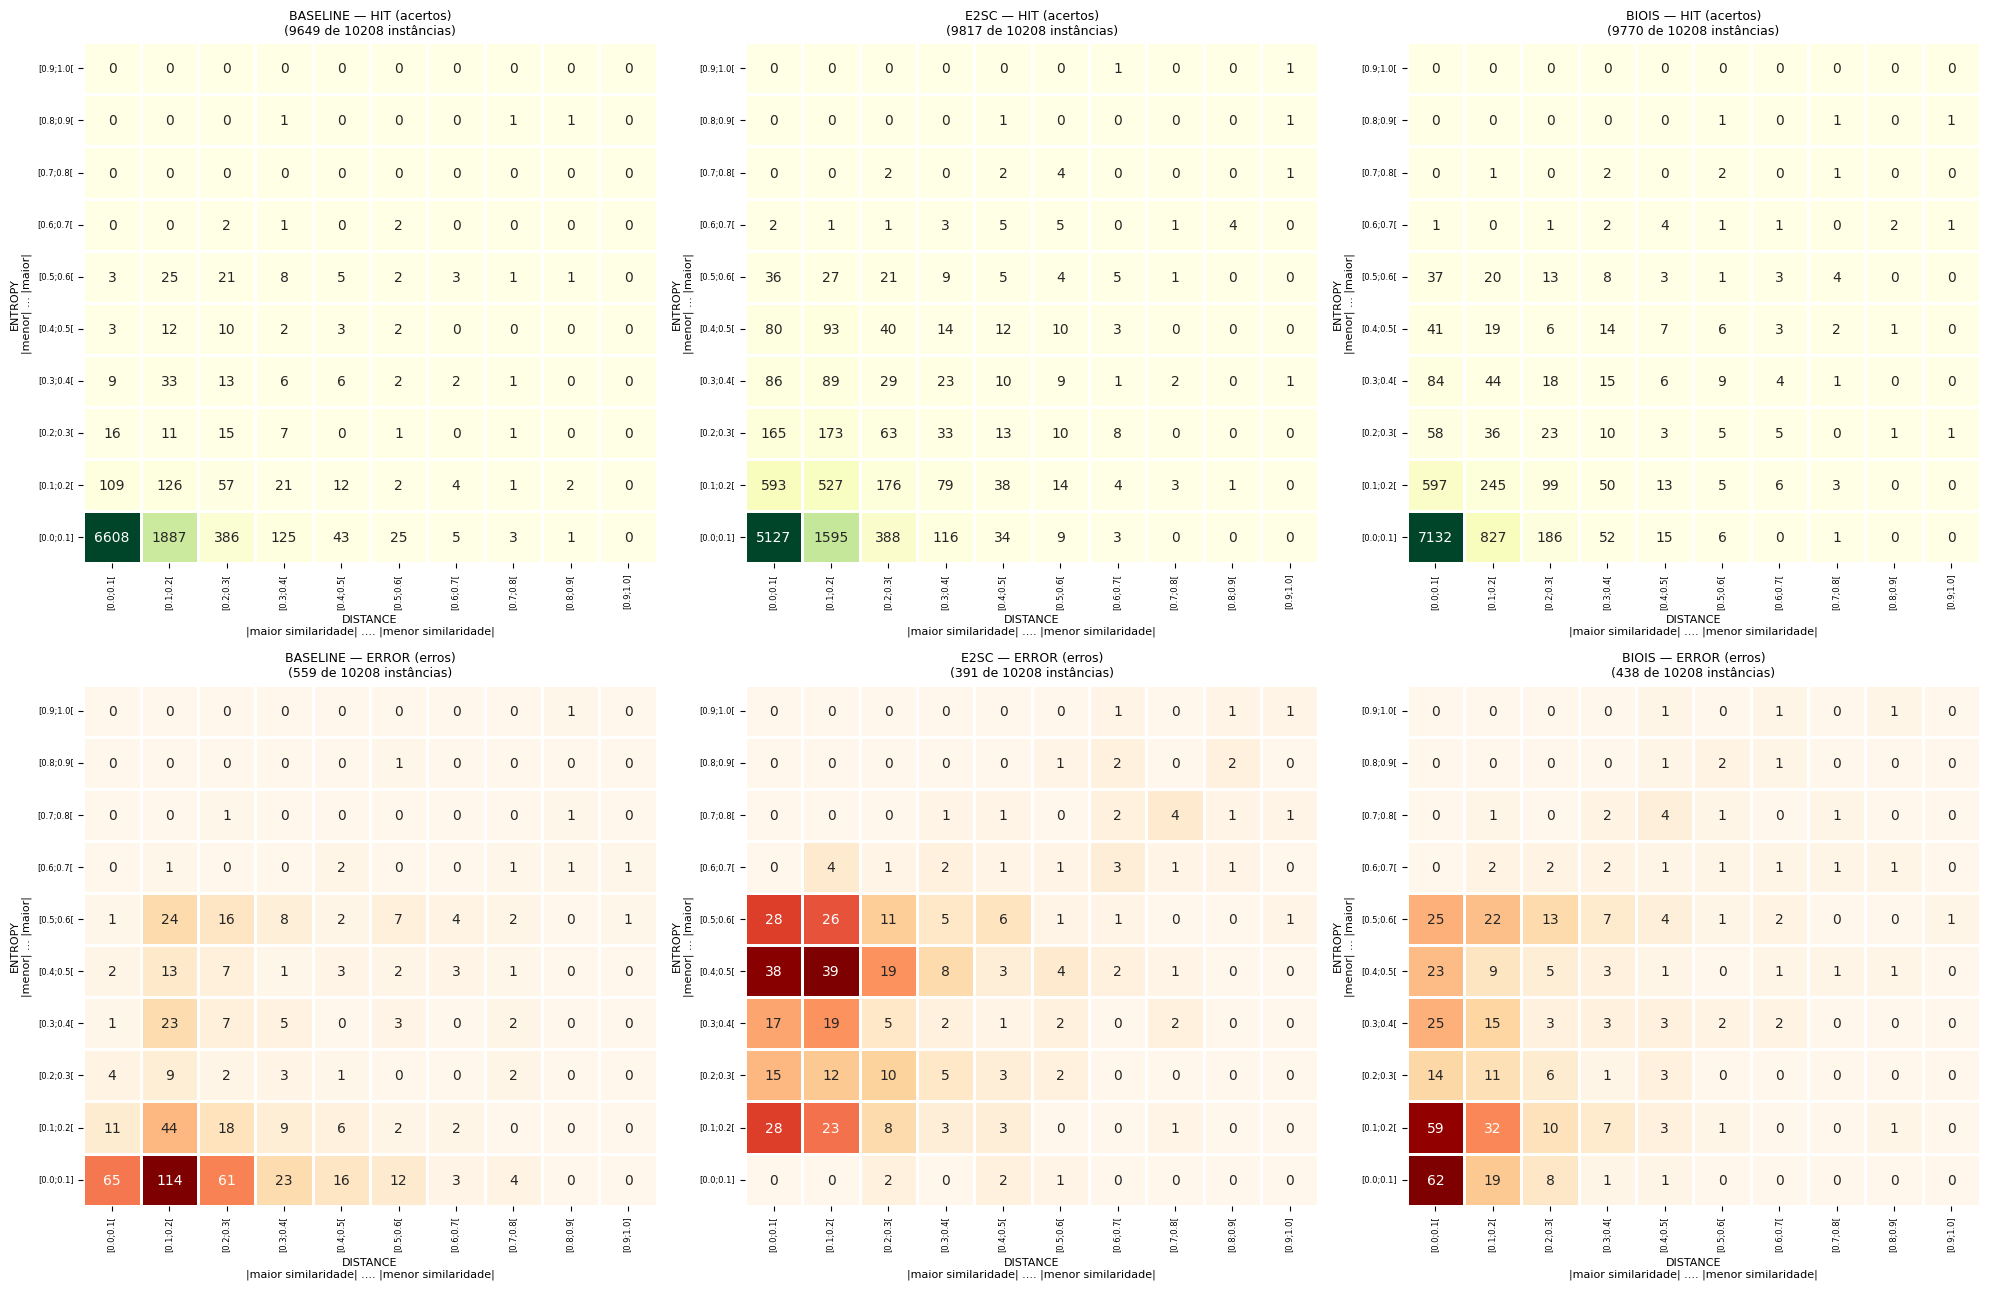

salvo: /kaggle/working/heatmaps_homogeneidade_3cenarios.png


In [5]:
import numpy as np, joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ---- carregar os três surveys ----
surveys = {
    "baseline": joblib.load("/kaggle/working/agnews0_baseline_cosine_survey.pkl"),
    "e2sc":     joblib.load("/kaggle/working/agnews0_e2sc_cosine_survey.pkl"),
    "biois":    joblib.load("/kaggle/working/agnews0_biois_cosine_survey.pkl"),
}

# ================= funções da Liziane (reproduzidas) =================
num_linhas = 10   # entropia
num_colunas = 10  # distância

entropy_intervals  = [(i/num_linhas,  (i+1)/num_linhas)  for i in range(num_linhas)]
distance_intervals = [(i/num_colunas, (i+1)/num_colunas) for i in range(num_colunas)]
entropy_lbls  = [f"[{a:.1f};{b:.1f}[" if i!=len(entropy_intervals)-1 else f"[{a:.1f};{b:.1f}]"
                 for i,(a,b) in enumerate(reversed(entropy_intervals))]
distance_lbls = [f"[{a:.1f};{b:.1f}[" if i!=len(distance_intervals)-1 else f"[{a:.1f};{b:.1f}]"
                 for i,(a,b) in enumerate(distance_intervals)]

def find_interval(value, intervals):
    for idx,(start,end) in enumerate(intervals):
        if start <= value < end:
            return idx
    return len(intervals)-1

def distribui_ids(data):
    matrix = [[[] for _ in range(num_colunas)] for _ in range(num_linhas)]
    for ident, ent, dist in data:
        ei = find_interval(ent,  entropy_intervals)
        di = find_interval(dist, distance_intervals)
        matrix[ei][di].append(ident)
    counts = np.array([[len(c) for c in row] for row in matrix])
    return counts[::-1]   # inverte linhas (entropia menor embaixo)

def plot_matriz(ax, counts, cmap, tipo, cenario, total):
    soma = counts.sum()
    sns.heatmap(counts, annot=True, fmt='g', ax=ax, linecolor='white', linewidth=1, cmap=cmap, cbar=False)
    ax.set_xlabel('DISTANCE\n|maior similaridade| .... |menor similaridade|', fontsize=8)
    ax.set_ylabel('ENTROPY\n|menor| ... |maior|', fontsize=8)
    ax.set_title(f'{cenario.upper()} — {tipo}\n({soma} de {total} instâncias)', fontsize=9)
    ax.set_xticklabels(distance_lbls, rotation=90, fontsize=6)
    ax.set_yticklabels(entropy_lbls, rotation=0, fontsize=6)

# ================= gerar os 6 heatmaps (3 cenários × HIT/ERROR) =================
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

for col, (nome, df) in enumerate(surveys.items()):
    total = len(df)
    # usa as colunas NORMALIZADas (entropy, avgdistance) — é o que define a grade
    df_hit = df[df["acerto"]]
    df_err = df[~df["acerto"]]

    triplas_hit = [(i, df_hit.loc[i,"entropy"], df_hit.loc[i,"avgdistance"]) for i in df_hit.index]
    triplas_err = [(i, df_err.loc[i,"entropy"], df_err.loc[i,"avgdistance"]) for i in df_err.index]

    plot_matriz(axes[0,col], distribui_ids(triplas_hit), "YlGn", "HIT (acertos)",  nome, total)
    plot_matriz(axes[1,col], distribui_ids(triplas_err), "OrRd", "ERROR (erros)", nome, total)

plt.tight_layout()
plt.savefig("/kaggle/working/heatmaps_homogeneidade_3cenarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("salvo: /kaggle/working/heatmaps_homogeneidade_3cenarios.png")

### 4.1 Heatmaps individuais (formato Soares 2025)
Versão com imagens separadas por cenário e tipo (HIT/ERROR), no formato original da tese, para o apêndice.

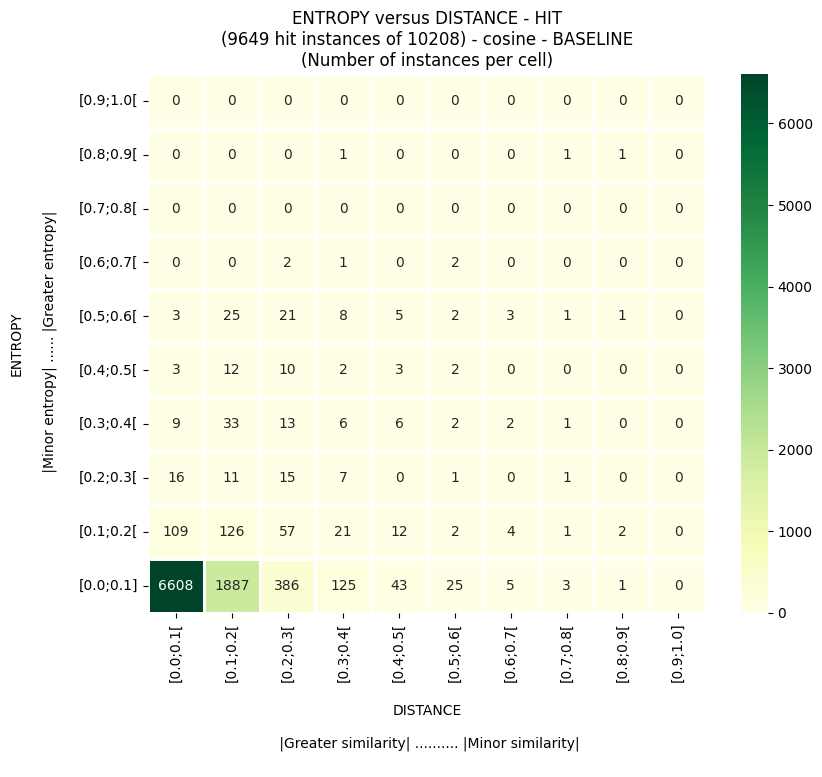

salvo: /kaggle/working/heatmap_baseline_mtxhit.png


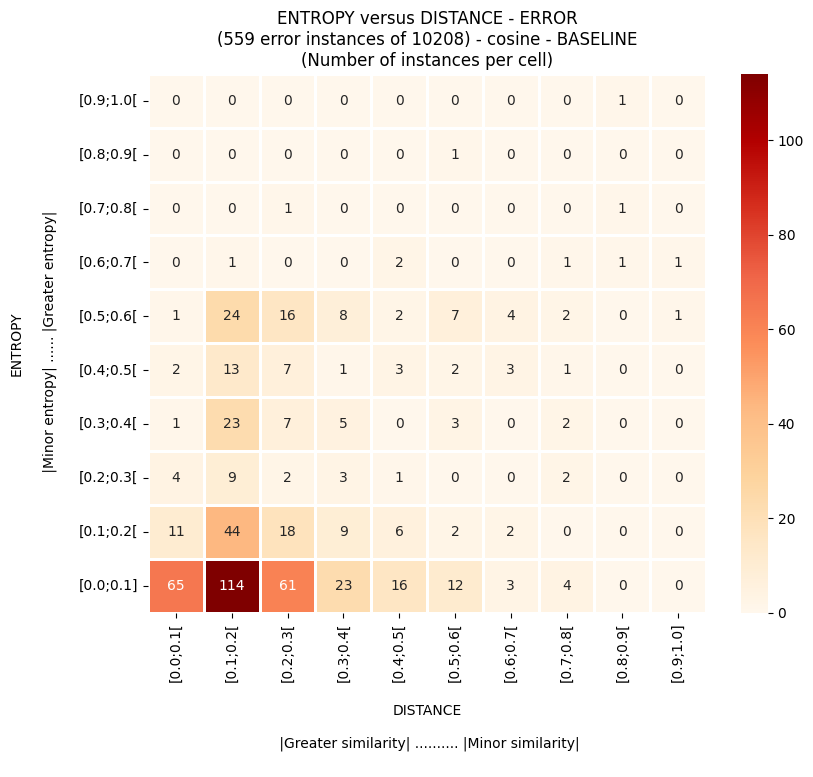

salvo: /kaggle/working/heatmap_baseline_mtxerror.png


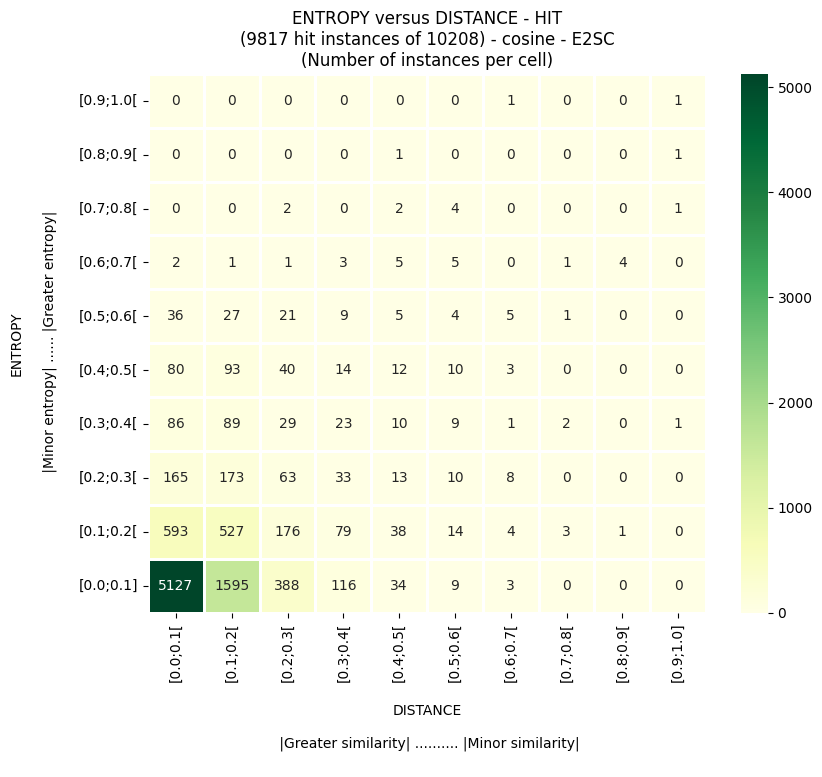

salvo: /kaggle/working/heatmap_e2sc_mtxhit.png


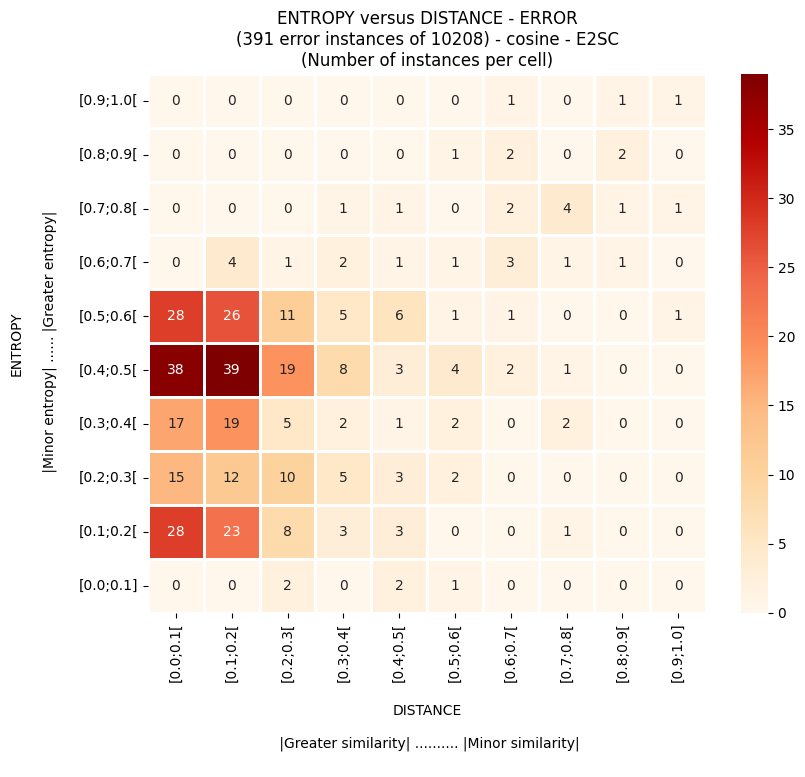

salvo: /kaggle/working/heatmap_e2sc_mtxerror.png


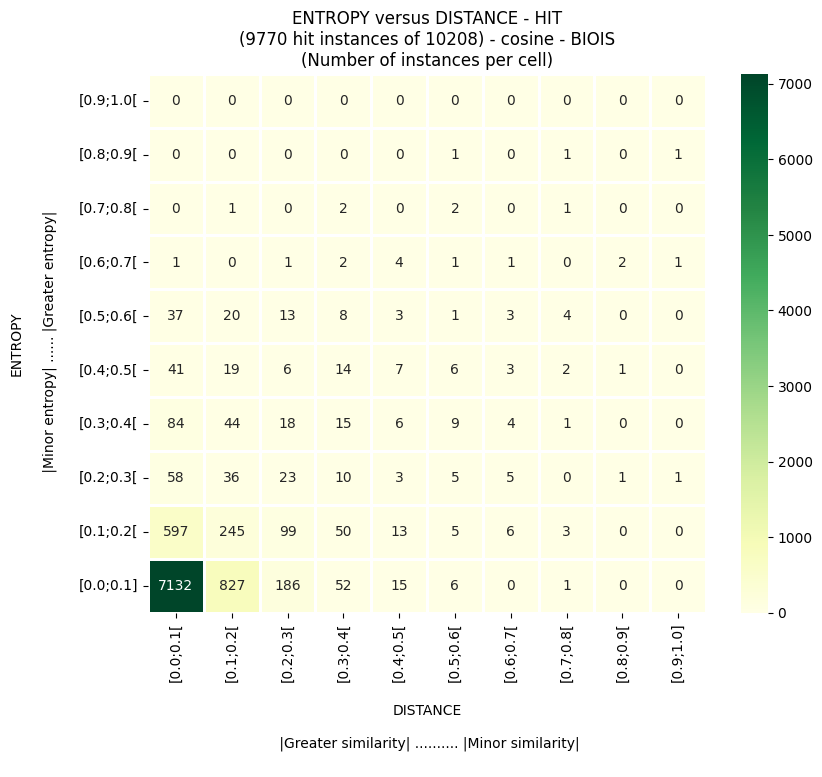

salvo: /kaggle/working/heatmap_biois_mtxhit.png


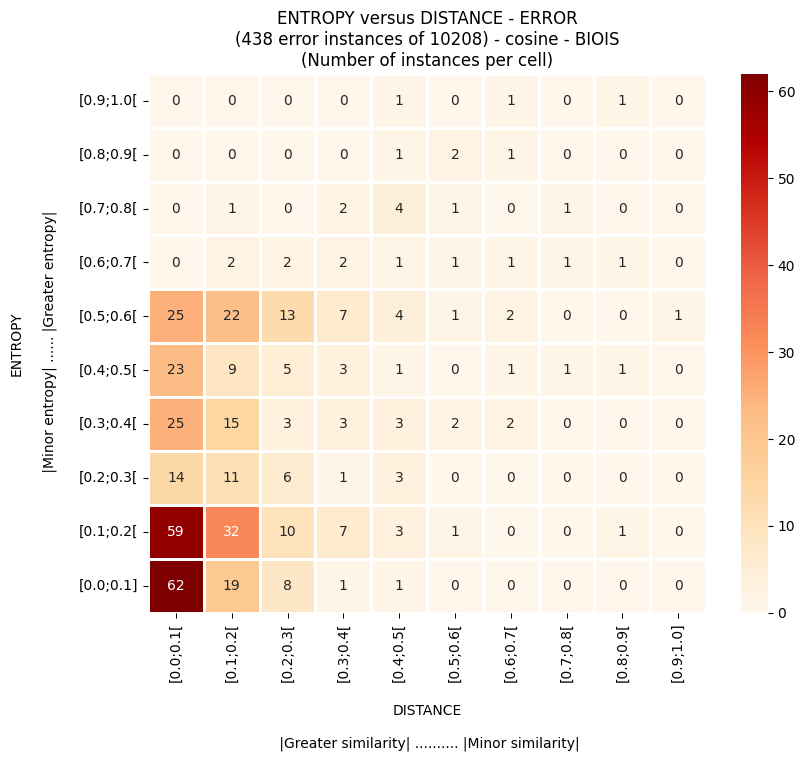

salvo: /kaggle/working/heatmap_biois_mtxerror.png


In [6]:
import numpy as np, joblib, glob
import matplotlib.pyplot as plt
import seaborn as sns

# carregar os três surveys (mesma fonte da grade 2x3)
def load_survey(nome):
    return joblib.load(glob.glob(f"/kaggle/working/agnews0_{nome}_cosine_survey.pkl")[0])

surveys = {"baseline": load_survey("baseline"), "e2sc": load_survey("e2sc"), "biois": load_survey("biois")}

# ---- parâmetros e intervalos (idênticos à Liziane) ----
num_linhas, num_colunas = 10, 10
entropy_intervals  = [(i/num_linhas,  (i+1)/num_linhas)  for i in range(num_linhas)]
distance_intervals = [(i/num_colunas, (i+1)/num_colunas) for i in range(num_colunas)]
entropy_fmt  = [f"[{a:.1f};{b:.1f}[" if i!=num_linhas-1  else f"[{a:.1f};{b:.1f}]" for i,(a,b) in enumerate(reversed(entropy_intervals))]
distance_fmt = [f"[{a:.1f};{b:.1f}[" if i!=num_colunas-1 else f"[{a:.1f};{b:.1f}]" for i,(a,b) in enumerate(distance_intervals)]

def find_interval(value, intervals):
    for idx,(start,end) in enumerate(intervals):
        if start <= value < end: return idx
    return len(intervals)-1

def distribui_ids(data):
    matrix = [[[] for _ in range(num_colunas)] for _ in range(num_linhas)]
    for ident, ent, dist in data:
        matrix[find_interval(ent, entropy_intervals)][find_interval(dist, distance_intervals)].append(ident)
    counts = np.array([[len(cell) for cell in row] for row in matrix])
    return counts[::-1]

def plot_matriz(counts, cmap, tipo, total, cenario):
    soma = counts.sum()
    fig, ax = plt.subplots(figsize=(9,7))
    sns.heatmap(counts, annot=True, fmt='g', ax=ax, linecolor='white', linewidth=1, cmap=cmap)
    ax.set_xlabel('\nDISTANCE\n\n |Greater similarity| .......... |Minor similarity|\n')
    ax.set_ylabel('ENTROPY\n\n |Minor entropy| ...... |Greater entropy|\n')
    ax.set_title(f'ENTROPY versus DISTANCE - {tipo}\n({soma} {tipo.lower()} instances of {total}) - cosine - {cenario.upper()}\n(Number of instances per cell)')
    ax.xaxis.set_ticklabels(distance_fmt, rotation='vertical')
    ax.yaxis.set_ticklabels(entropy_fmt, rotation='horizontal')
    out = f"/kaggle/working/heatmap_{cenario}_mtx{tipo.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("salvo:", out)

# ---- gerar as 6 imagens (3 cenários × HIT/ERROR) ----
for cenario, df in surveys.items():
    total = len(df)
    df_hit = df[df["acerto"]]
    df_err = df[~df["acerto"]]
    triplas_hit = [(i, df_hit.loc[i,"entropy"], df_hit.loc[i,"avgdistance"]) for i in df_hit.index]
    triplas_err = [(i, df_err.loc[i,"entropy"], df_err.loc[i,"avgdistance"]) for i in df_err.index]
    plot_matriz(distribui_ids(triplas_hit), "YlGn", "HIT",   total, cenario)
    plot_matriz(distribui_ids(triplas_err), "OrRd", "ERROR", total, cenario)

## 5. Métricas globais de localidade

Entropia e similaridade médias do conjunto de teste completo (10.208 instâncias) nos três cenários, em valores brutos comparáveis.

In [7]:
import joblib

print("Médias BRUTAS do conjunto de teste (10208 instâncias):\n")
print(f"{'cenário':10s} {'entropia média':>16s} {'distância média':>16s}")
for nome, path in [("baseline","agnews0_baseline"),("E2SC","agnews0_e2sc"),("biO-IS","agnews0_biois")]:
    df = joblib.load(f"/kaggle/working/{path}_cosine_survey.pkl")
    print(f"{nome:10s} {df['entropy_raw'].mean():>16.4f} {df['avgdistance_raw'].mean():>16.4f}")

print("\n(entropia menor = mais homogêneo | distância menor = vizinhos mais próximos)")

Médias BRUTAS do conjunto de teste (10208 instâncias):

cenário      entropia média  distância média
baseline             0.0407           0.0701
E2SC                 0.1406           0.0614
biO-IS               0.0829           0.0460

(entropia menor = mais homogêneo | distância menor = vizinhos mais próximos)


## 6. Distribuição da homogeneidade por faixa de entropia

Análise da distribuição das instâncias de teste por faixa de entropia nos três cenários, complementando as métricas médias. Quantifica também a concentração no quadrante de alta homogeneidade (entropia e distância baixas), respondendo diretamente à pergunta de pesquisa.

In [8]:
import joblib, pandas as pd, numpy as np

surveys = {
    "Baseline": joblib.load("/kaggle/working/agnews0_baseline_cosine_survey.pkl"),
    "E2SC":     joblib.load("/kaggle/working/agnews0_e2sc_cosine_survey.pkl"),
    "biO-IS":   joblib.load("/kaggle/working/agnews0_biois_cosine_survey.pkl"),
}

# faixas de entropia normalizada
faixas = [(0.0,0.1),(0.1,0.3),(0.3,0.5),(0.5,0.7),(0.7,1.01)]
nomes_faixa = ["Muito baixa [0–0.1)","Baixa [0.1–0.3)","Média [0.3–0.5)","Alta [0.5–0.7)","Muito alta [0.7–1.0]"]

print(f"{'Faixa de entropia':22s} {'Baseline':>10s} {'E2SC':>10s} {'biO-IS':>10s}")
print("-"*54)
tabela = {}
for (lo,hi), nome in zip(faixas, nomes_faixa):
    linha = {}
    for cen, df in surveys.items():
        ent = df["entropy"]  # normalizada
        n = ((ent >= lo) & (ent < hi)).sum()
        pct = 100*n/len(df)
        linha[cen] = f"{n} ({pct:.1f}%)"
    tabela[nome] = linha
    print(f"{nome:22s} {linha['Baseline']:>10s} {linha['E2SC']:>10s} {linha['biO-IS']:>10s}")

# também: quantas estão na região de ALTA homogeneidade (entropia E distância baixas)
print("\n=== Instâncias na região de ALTA HOMOGENEIDADE (entropia<0.1 E distância<0.1) ===")
for cen, df in surveys.items():
    n = ((df["entropy"]<0.1) & (df["avgdistance"]<0.1)).sum()
    print(f"  {cen:10s}: {n} ({100*n/len(df):.1f}%)")

Faixa de entropia        Baseline       E2SC     biO-IS
------------------------------------------------------
Muito baixa [0–0.1)    9381 (91.9%) 7277 (71.3%) 8310 (81.4%)
Baixa [0.1–0.3)        498 (4.9%) 2013 (19.7%) 1308 (12.8%)
Média [0.3–0.5)        177 (1.7%) 664 (6.5%) 377 (3.7%)
Alta [0.5–0.7)         145 (1.4%) 223 (2.2%) 188 (1.8%)
Muito alta [0.7–1.0]     7 (0.1%)  31 (0.3%)  25 (0.2%)

=== Instâncias na região de ALTA HOMOGENEIDADE (entropia<0.1 E distância<0.1) ===
  Baseline  : 6673 (65.4%)
  E2SC      : 5127 (50.2%)
  biO-IS    : 7194 (70.5%)


## Apêndice - Análise de Estabilidade (exploratória)

Análise complementar de estabilidade de termos sob perturbação de ruído. **Não faz parte das entregas do pré-projeto** - mantida para referência e trabalhos futuros (mestrado).

In [9]:
# ANÁLISE DAS 16 — embeddings REAIS (lê do dataset de embeddings)
import pandas as pd, numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy as shannon_entropy

EMB = "/kaggle/input/datasets/karinabatista/agnews-embeddings-is-xai"
base = "/kaggle/input/datasets/claudiovaliense/datasets-lbd3/agnews"

# embeddings (teste=consulta, treino=vizinhos)
e2sc_test   = pd.read_pickle(f"{EMB}/agnews_e2sc_representation.pkl")
e2sc_train  = pd.read_pickle(f"{EMB}/agnews_e2sc_train_representation.pkl")
biois_test  = pd.read_pickle(f"{EMB}/agnews_biois_representation.pkl")
biois_train = pd.read_pickle(f"{EMB}/agnews_biois_train_representation.pkl")

# idx_in_orig no teste, via split do fold 0
splits = pd.read_pickle(f"{base}/splits/split_5_with_val.pkl")
test_idxs = list(splits.iloc[0]['test_idxs'])
e2sc_test['idx_in_orig']  = test_idxs
biois_test['idx_in_orig'] = test_idxs

inst16 = {64797:'HIT-High',63274:'HIT-High',126923:'HIT-High',71552:'HIT-High',
          15028:'HIT-Low',76918:'HIT-Low',107040:'HIT-Low',109385:'HIT-Low',
          71095:'ERR-High',30377:'ERR-High',31229:'ERR-High',8840:'ERR-High',
          29347:'ERR-Low',7260:'ERR-Low',97727:'ERR-Low',31562:'ERR-Low'}

def localidade(test_df, train_df, nome, k=30):
    Xtr = np.vstack(train_df['bert'].values)
    ytr = train_df['labels'].values
    knn = NearestNeighbors(n_neighbors=k, metric='cosine').fit(Xtr)
    linhas=[]
    for idx, grupo in inst16.items():
        row = test_df[test_df['idx_in_orig']==idx]
        if len(row)==0: continue
        emb = np.array(row['bert'].values[0]).reshape(1,-1)
        dist, viz = knn.kneighbors(emb)
        _, counts = np.unique(ytr[viz[0]], return_counts=True)
        linhas.append({'idx':idx,'grupo':grupo,
                       f'ent_{nome}':round(shannon_entropy(counts,base=2),3)})
    return pd.DataFrame(linhas)

r_e = localidade(e2sc_test, e2sc_train, 'e2sc')
r_b = localidade(biois_test, biois_train, 'biois')
comp = r_e.merge(r_b[['idx','ent_biois']], on='idx')

comp['homog'] = comp['grupo'].str.contains('High').map({True:'High',False:'Low'})
print("=== ENTROPIA MÉDIA por homogeneidade (embeddings REAIS) ===")
print(comp.groupby('homog')[['ent_e2sc','ent_biois']].mean().round(3))
print("\n=== detalhe das 16 ===")
print(comp[['idx','grupo','ent_e2sc','ent_biois']].to_string(index=False))

=== ENTROPIA MÉDIA por homogeneidade (embeddings REAIS) ===
       ent_e2sc  ent_biois
homog                     
High      0.141      0.053
Low       0.591      0.749

=== detalhe das 16 ===
   idx    grupo  ent_e2sc  ent_biois
 64797 HIT-High     0.000      0.000
 63274 HIT-High     0.000      0.000
126923 HIT-High     0.000      0.000
 71552 HIT-High     0.000      0.000
 15028  HIT-Low     0.353      0.675
 76918  HIT-Low     0.469      0.906
107040  HIT-Low     0.000      1.183
109385  HIT-Low     0.211      0.420
 71095 ERR-High     0.353      0.000
 30377 ERR-High     0.353      0.000
 31229 ERR-High     0.211      0.211
  8840 ERR-High     0.211      0.211
 29347  ERR-Low     1.438      0.353
  7260  ERR-Low     0.561      0.353
 97727  ERR-Low     0.353      1.538
 31562  ERR-Low     1.347      0.561


In [10]:
# ESTABILIDADE alinhada ao método da Liziane (NearestNeighbors + clean_text completo)
import re
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

# clean_text EXATO da Liziane (versão AGNews)
base_name = "agnews"
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    remove_days = ['sunday','monday','tuesday','wednesday','thursday','friday','saturday']
    remove_months = ["january","february","march","april","may","june","july","august",
                     "september","october","november","ecember","today","tomorrow","yesterday"]
    text = re.sub(r'\b(?:' + '|'.join(remove_days+remove_months) + r')\b', '', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?\b', '', text)
    text = re.sub(r'\b\d{1,2} ?(?:hours?|minutes?|seconds?)\b', '', text)
    text = re.sub(r'\B#\w+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&\w+;', '', text)
    if base_name == "agnews":
        removed_terms = ["(cp)","(U.S.)","U.S.","u s"," us","u n","(AFP)","(afp)","AFP","afp"," th",
            "gt","lt","co","uk","jhtml","ticker","financequotelookup","qcat","fullquote","aspx",
            "infotype","info","qtype","sym","=news","(ap)","ap","(AP)","quickinfo/","reuters"," n&",
            " n ","cr","f","associated press","b","canadian press","com","cp","href","http","least",
            "mdt","n","new","quot","quoted","rcmp","said","say","says","u$","www"]
    else:
        removed_terms = []
    for term in removed_terms:
        text = re.sub(r'\b'+re.escape(term)+r'\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b\w{1,2}\b', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else 1.0

def termos_viz(idx_vizinhos, textos, max_words=25):
    text = clean_text(" ".join(textos[i] for i in idx_vizinhos))
    tokens = [w for w in re.findall(r"[a-z]{3,}", text) if w not in STOP_WORDS]
    return set(w for w, _ in Counter(tokens).most_common(max_words))

def estabilidade(emb_consulta, knn, emb_train, textos, k=30, max_words=25,
                 noise_scale=0.05, n_trials=20, seed=0):
    rng = np.random.default_rng(seed)
    _, base_viz = knn.kneighbors(emb_consulta.reshape(1,-1))
    base_viz = set(base_viz[0])
    base_terms = termos_viz(list(base_viz), textos, max_words)
    sigma = noise_scale * np.linalg.norm(emb_consulta)
    jn, jt = [], []
    for _ in range(n_trials):
        noisy = emb_consulta + rng.normal(0, sigma, size=emb_consulta.shape)
        _, pert = knn.kneighbors(noisy.reshape(1,-1))
        pert = set(pert[0])
        jn.append(jaccard(base_viz, pert))
        jt.append(jaccard(base_terms, termos_viz(list(pert), textos, max_words)))
    return float(np.mean(jn)), float(np.mean(jt))

def estabilidade_16(test_df, train_df, nome):
    Xtr = np.vstack(train_df['bert'].values)
    textos = train_df['text'].tolist()
    knn = NearestNeighbors(n_neighbors=30, metric='cosine').fit(Xtr)
    linhas=[]
    for idx, grupo in inst16.items():
        row = test_df[test_df['idx_in_orig']==idx]
        if len(row)==0: continue
        emb = np.array(row['bert'].values[0])
        jn, jt = estabilidade(emb, knn, Xtr, textos)
        linhas.append({'idx':idx,'grupo':grupo,
                       f'estab_viz_{nome}':round(jn,3), f'estab_term_{nome}':round(jt,3)})
    return pd.DataFrame(linhas)

est_e = estabilidade_16(e2sc_test, e2sc_train, 'e2sc')
est_b = estabilidade_16(biois_test, biois_train, 'biois')
est = est_e.merge(est_b[['idx','estab_viz_biois','estab_term_biois']], on='idx')
est['homog'] = est['grupo'].str.contains('High').map({True:'High',False:'Low'})

print("=== ESTABILIDADE MÉDIA por homogeneidade (1=estável) ===")
print(est.groupby('homog')[['estab_viz_e2sc','estab_viz_biois']].mean().round(3))
print("\n=== detalhe (estabilidade de vizinhos) ===")
print(est[['idx','grupo','estab_viz_e2sc','estab_viz_biois']].to_string(index=False))

=== ESTABILIDADE MÉDIA por homogeneidade (1=estável) ===
       estab_viz_e2sc  estab_viz_biois
homog                                 
High            0.329            0.239
Low             0.555            0.523

=== detalhe (estabilidade de vizinhos) ===
   idx    grupo  estab_viz_e2sc  estab_viz_biois
 64797 HIT-High           0.088            0.079
 63274 HIT-High           0.185            0.272
126923 HIT-High           0.383            0.240
 71552 HIT-High           0.478            0.227
 15028  HIT-Low           0.675            0.445
 76918  HIT-Low           0.501            0.452
107040  HIT-Low           0.605            0.550
109385  HIT-Low           0.387            0.311
 71095 ERR-High           0.593            0.434
 30377 ERR-High           0.544            0.466
 31229 ERR-High           0.223            0.093
  8840 ERR-High           0.135            0.104
 29347  ERR-Low           0.568            0.501
  7260  ERR-Low           0.597            0.673
 97727  

In [11]:
print("=== ESTABILIDADE DE TERMOS por homogeneidade ===")
print(est.groupby('homog')[['estab_term_e2sc','estab_term_biois']].mean().round(3))

=== ESTABILIDADE DE TERMOS por homogeneidade ===
       estab_term_e2sc  estab_term_biois
homog                                   
High             0.471             0.391
Low              0.517             0.468
